<a href="https://colab.research.google.com/github/Niranjan1422/Infosys_Internship/blob/main/Knowledge_Graph_Movies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import zipfile
import os

# Path to the ZIP file in Google Drive
zip_file_path = "/content/drive/MyDrive/Infosys_Datasets_Proj/archive (10).zip"
# Name of the specific CSV file inside the ZIP
csv_file_in_zip = "movies_metadata.csv"
# Temporary directory to extract the CSV
extract_dir = "/tmp/extracted_data"
extracted_csv_path = os.path.join(extract_dir, csv_file_in_zip)

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

try:
    # Open the ZIP file
    with zipfile.ZipFile(zip_file_path, 'r') as zf:
        # Check if the desired CSV file exists within the zip archive
        if csv_file_in_zip in zf.namelist():
            # Extract the specific CSV file
            zf.extract(csv_file_in_zip, extract_dir)
            # Read the extracted CSV file into a DataFrame
            df = pd.read_csv(extracted_csv_path)
            print(f"Successfully loaded '{csv_file_in_zip}' into a DataFrame.")
            print(f"DataFrame head:\n{df.head()}")
        else:
            print(f"Error: '{csv_file_in_zip}' not found inside '{zip_file_path}'.")
            print("Files available in the ZIP archive:", zf.namelist())
except FileNotFoundError:
    print(f"Error: The ZIP file '{zip_file_path}' was not found. Please ensure the path is correct and your Google Drive is mounted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


In [31]:
pip install pandas networkx

In [32]:
import pandas as pd
import networkx as nx
import json

# Load the movies metadata (the 'df' DataFrame is already loaded from the previous cell)
# Using the already loaded 'df' DataFrame for efficiency.
# If you needed to reload, you would use: movies = pd.read_csv(extracted_csv_path, low_memory=False)
movies = df.copy()

# Inspect to confirm columns
print(movies.columns[:10])

# Create directed graph
G = nx.DiGraph()

# Process first 500 movies for demo
movies_subset = movies.head(500)

for idx, row in movies_subset.iterrows():
    movie_id = row.get("id")
    title = row.get("title", "Unknown Title")
    language = row.get("original_language")

    # Add movie node
    G.add_node(movie_id, label="Movie", title=title)

    # Add language node & relation
    if pd.notna(language):
        G.add_node(language, label="Language")
        G.add_edge(movie_id, language, relation="IN_LANGUAGE")

    # Genres: stored as stringified JSON; parse if present
    genre_info = row.get("genres")
    if pd.notna(genre_info):
        try:
            genres = json.loads(genre_info.replace("'", '"'))
            for g in genres:
                genre_name = g.get("name")
                if genre_name:
                    G.add_node(genre_name, label="Genre")
                    G.add_edge(movie_id, genre_name, relation="HAS_GENRE")
        except:
            pass

    # Production companies similarly
    prod_info = row.get("production_companies")
    if pd.notna(prod_info):
        try:
            comps = json.loads(prod_info.replace("'", '"'))
            for comp in comps:
                comp_name = comp.get("name")
                if comp_name:
                    G.add_node(comp_name, label="ProductionCompany")
                    G.add_edge(movie_id, comp_name, relation="MADE_BY")
        except:
            pass

print("Nodes:", len(G.nodes()), "Edges:", len(G.edges()))

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview'],
      dtype='object')
Nodes: 1020 Edges: 2754


In [33]:
genres = [n for n, d in G.nodes(data=True) if d.get("label") == "Genre"]
print("Genres in graph:", genres)

Genres in graph: ['Animation', 'Comedy', 'Family', 'Adventure', 'Fantasy', 'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror', 'History', 'Science Fiction', 'Mystery', 'War', 'Foreign', 'Music', 'Documentary', 'Western', 'TV Movie']


In [34]:
movie_to_query = "The Matrix"  # Example title
movie_nodes = [(n,d) for n,d in G.nodes(data=True) if d.get("label")=="Movie" and d.get("title")==movie_to_query]

if movie_nodes:
    node_id = movie_nodes[0][0]
    for s,t,d in G.out_edges(node_id, data=True):
        print(f"{movie_to_query} -[{d['relation']}]-> {t}")
else:
    print("Movie not in subset.")

Movie not in subset.


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [36]:
movie_to_query = "Clueless"  # Example title
movie_nodes = [(n,d) for n,d in G.nodes(data=True) if d.get("label")=="Movie" and d.get("title")==movie_to_query]

if movie_nodes:
    node_id = movie_nodes[0][0]
    for s,t,d in G.out_edges(node_id, data=True):
        print(f"{movie_to_query} -[{d['relation']}]-> {t}")
else:
    print("Movie not in subset.")

Clueless -[IN_LANGUAGE]-> en
Clueless -[HAS_GENRE]-> Comedy
Clueless -[HAS_GENRE]-> Drama
Clueless -[HAS_GENRE]-> Romance
Clueless -[MADE_BY]-> Paramount Pictures


In [37]:
#Install Neo4j Python Driver in Colab

In [38]:
pip install neo4j pandas

In [39]:
import pandas as pd
import zipfile
import os

# Reusing variables from the initial extraction in cell b87T10GGfF_N
zip_file_path = "/content/drive/MyDrive/Infosys_Datasets_Proj/archive (10).zip"
extract_dir = "/tmp/extracted_data"
# Ensure the extraction directory exists (it should from the previous cell, but good practice)
os.makedirs(extract_dir, exist_ok=True)

# 'movies_metadata.csv' is already loaded into `df` from the previous cell.
# We can assign it to `movies` for consistency with the cell's original intent.
movies = df.copy() # Use a copy if you intend to modify 'movies' independently later.

# Define the other CSV files to extract and load
csv_files_to_load = ["credits.csv", "keywords.csv"]
loaded_dataframes = {}

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zf:
        zip_contents = zf.namelist()
        for csv_file_name in csv_files_to_load:
            if csv_file_name in zip_contents:
                extracted_path = os.path.join(extract_dir, csv_file_name)
                zf.extract(csv_file_name, extract_dir)
                loaded_dataframes[csv_file_name.replace('.csv', '')] = pd.read_csv(extracted_path)
                print(f"Successfully loaded '{csv_file_name}'.")
            else:
                print(f"Error: '{csv_file_name}' not found inside '{zip_file_path}'.")
                print("Files available in the ZIP archive:", zip_contents)

    credits = loaded_dataframes.get('credits')
    keywords = loaded_dataframes.get('keywords')

    # Print shapes if all dataframes were successfully loaded
    if credits is not None and keywords is not None:
        print(movies.shape, credits.shape, keywords.shape)
    else:
        print("Some dataframes could not be loaded.")

except FileNotFoundError:
    print(f"Error: The ZIP file '{zip_file_path}' was not found. Please ensure the path is correct and your Google Drive is mounted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully loaded 'credits.csv'.
Successfully loaded 'keywords.csv'.
(45466, 24) (45476, 3) (46419, 2)


In [40]:
#Clean & Select Required Columns

movies = movies[['id','title','original_language','release_date','genres']]
credits = credits[['id','cast','crew']]
keywords = keywords[['id','keywords']]

movies = movies.dropna(subset=['id','title'])

In [41]:
#Connect to Neo4j from Colab

from neo4j import GraphDatabase

URI = "neo4j+s://e27135de.databases.neo4j.io"
AUTH = ("neo4j", "WkmpufxtnWTdPav7XT1Ae9KD-_5H30FodCux9HlQLYY")

driver = GraphDatabase.driver(URI, auth=AUTH)

In [42]:
def insert_movie(tx, movie_id, title, lang, date):
    tx.run("""
    MERGE (m:Movie {id:$id})
    SET m.title=$title,
        m.language=$lang,
        m.release_date=$date
    """, id=movie_id, title=title, lang=lang, date=date)

with driver.session() as session:
    for _, row in movies.head(1000).iterrows():  # demo subset
        session.execute_write(
            insert_movie,
            row['id'], row['title'],
            row['original_language'], row['release_date']
        )

In [43]:
#Version

import neo4j
print(neo4j.__version__)

6.1.0


In [44]:
movies_clean = movies.copy()

# Convert id to numeric and drop bad rows
movies_clean['id'] = pd.to_numeric(movies_clean['id'], errors='coerce')
movies_clean = movies_clean.dropna(subset=['id', 'title'])

# Convert id to int
movies_clean['id'] = movies_clean['id'].astype(int)

movies_clean = movies_clean.head(1000)
print(movies_clean.shape)

(1000, 5)


In [45]:
from neo4j import GraphDatabase

URI = "neo4j+s://e27135de.databases.neo4j.io"
AUTH = ("neo4j", "WkmpufxtnWTdPav7XT1Ae9KD-_5H30FodCux9HlQLYY")

driver = GraphDatabase.driver(URI, auth=AUTH)

In [46]:
#Insert Movies into Neo4j

def insert_movie(tx, movie_id, title, lang, date):
    tx.run(
        """
        MERGE (m:Movie {id: $id})
        SET m.title = $title,
            m.language = $lang,
            m.release_date = $date
        """,
        id=movie_id,
        title=title,
        lang=lang,
        date=date
    )

In [47]:
with driver.session() as session:
    for _, row in movies_clean.iterrows():
        session.execute_write(
            insert_movie,
            row['id'],
            row['title'],
            row['original_language'],
            row['release_date']
        )

print("✅ Movies inserted successfully")

✅ Movies inserted successfully


In [48]:
with driver.session() as session:
    result = session.run("RETURN 1 AS test")
    print(result.single()["test"])

1


In [49]:
with driver.session() as session:
    session.run("""
        MERGE (m:Movie {id: 999999})
        SET m.title = 'Test Movie'
    """)
print("Single insert OK")

Single insert OK


In [50]:
count = 0

with driver.session() as session:
    for _, row in movies_clean.head(50).iterrows():  # START SMALL
        session.run(
            """
            MERGE (m:Movie {id: $id})
            SET m.title = $title,
                m.language = $lang,
                m.release_date = $date
            """,
            id=int(row['id']),
            title=str(row['title']),
            lang=str(row['original_language']),
            date=str(row['release_date'])
        )
        count += 1

print(f"✅ Inserted {count} movies")

✅ Inserted 50 movies


In [51]:
with driver.session() as session:
    for _, row in movies_clean.head(100).iterrows():
        session.run(
            """
            MERGE (m:Movie {id: $id})
            SET m.title = $title,
                m.language = $lang,
                m.release_date = $date
            """,
            id=int(row['id']),
            title=str(row['title']),
            lang=str(row['original_language']),
            date=str(row['release_date'])
        )

print("✅ Movies inserted successfully")

✅ Movies inserted successfully


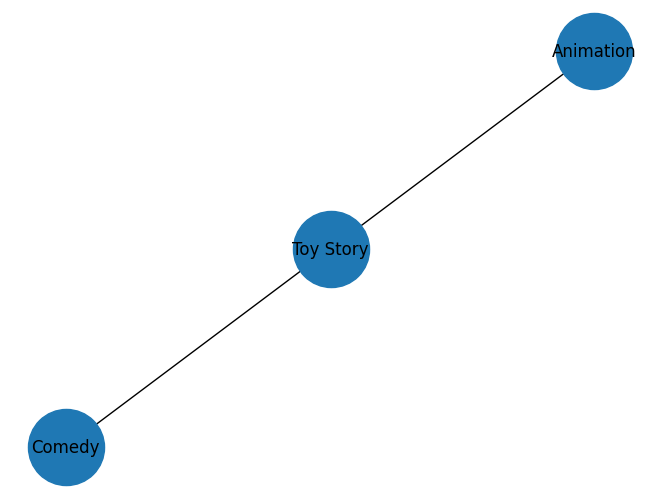

In [52]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_edge("Toy Story", "Animation")
G.add_edge("Toy Story", "Comedy")

nx.draw(G, with_labels=True, node_size=3000)
plt.show()

In [53]:
with driver.session() as session:
    result = session.run("""
    CALL apoc.export.csv.query(
      "MATCH (m:Movie)-[:HAS_GENRE]->(g:Genre)
       RETURN m.title AS movie, g.name AS genre",
      null,
      {stream:true}
    )
    """)
    record = result.single()
    csv_data = record["data"]

with open("movies_genres.csv", "w", encoding="utf-8") as f:
    f.write(csv_data)

In [54]:
query = """
MATCH (m:Movie)-[:HAS_GENRE]->(g:Genre)
RETURN m.title AS movie, g.name AS genre
LIMIT 500
"""

with driver.session() as session:
    result = session.run(query)
    df = pd.DataFrame([r.data() for r in result])

df.to_csv("movies_genres.csv", index=False)
df.head()

,movie,genre
0,Toy Story,Animation
1,Balto,Animation
2,Pocahontas,Animation
3,A Goofy Movie,Animation
4,Gumby: The Movie,Animation


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('movie').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('index', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('movie')):
  _plot_series(series, series_name, i)
  fig.legend(title='movie', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_3['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_4['movie'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_4, x='index', y='movie', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)